RNN — MIT-BIH ECG Time-Series

CELL 1 — Install & Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score)
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, Dense, Dropout,
                                     BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)
print("All libraries loaded ✅")

TensorFlow Version: 2.21.0
All libraries loaded ✅


CELL 2 — Load Dataset

In [3]:

train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df  = pd.read_csv("mitbih_test.csv",  header=None)

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print("✅ Dataset loaded successfully!")

Train shape: (87554, 188)
Test  shape: (21892, 188)
✅ Dataset loaded successfully!


CELL 3 — Explore Data

=== Class Distribution (Train) ===
187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64


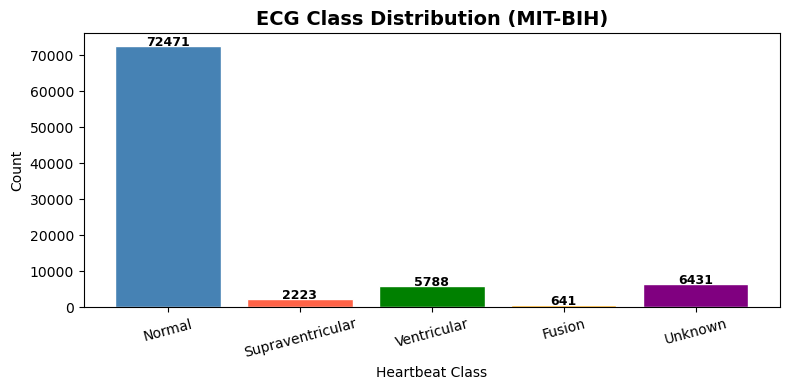

In [4]:
class_names = {
    0: 'Normal',
    1: 'Supraventricular',
    2: 'Ventricular',
    3: 'Fusion',
    4: 'Unknown'
}

print("=== Class Distribution (Train) ===")
print(train_df[187].value_counts().sort_index())

# Plot
plt.figure(figsize=(8, 4))
counts = train_df[187].value_counts().sort_index()
bars = plt.bar(
    [class_names[i] for i in counts.index],
    counts.values,
    color=['steelblue','tomato','green','orange','purple'],
    edgecolor='white'
)
plt.title('ECG Class Distribution (MIT-BIH)', fontsize=14, fontweight='bold')
plt.xlabel('Heartbeat Class')
plt.ylabel('Count')
plt.xticks(rotation=15)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             str(val), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('rnn_class_distribution.png', dpi=150)
plt.show()

CELL 4 — Visualize Sample ECG Signals

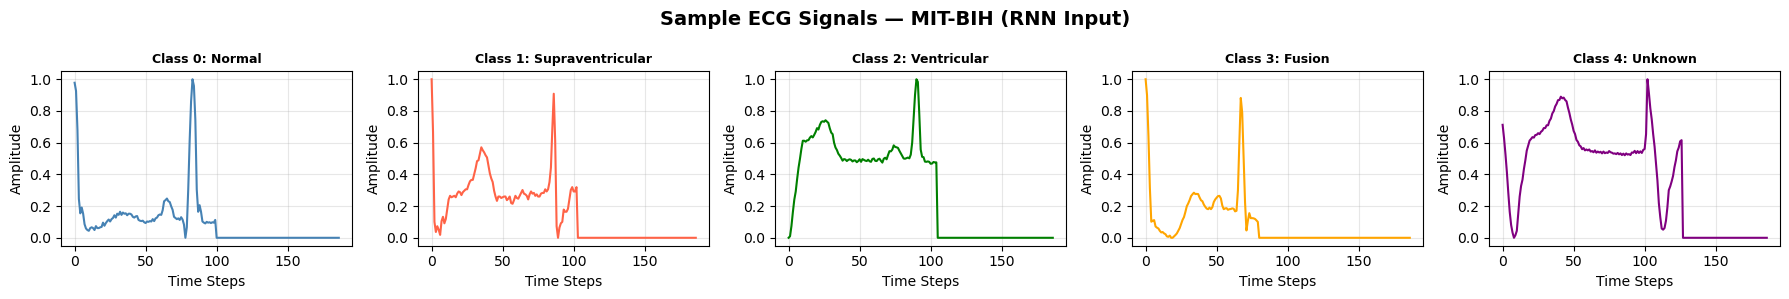

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
colors = ['steelblue','tomato','green','orange','purple']

for i in range(5):
    sample = train_df[train_df[187] == i].iloc[0, :187].values
    axes[i].plot(sample, color=colors[i], linewidth=1.5)
    axes[i].set_title(f'Class {i}: {class_names[i]}',
                      fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Time Steps')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Sample ECG Signals — MIT-BIH (RNN Input)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rnn_sample_signals.png', dpi=150)
plt.show()

CELL 5 — Add Class Weights

In [12]:
from collections import Counter
from sklearn.utils import resample, class_weight

# Split features and labels
X_train = train_df.iloc[:, :187].values
y_train = train_df[187].values.astype(int)
X_test  = test_df.iloc[:, :187].values
y_test  = test_df[187].values.astype(int)

print("Before balancing:", Counter(y_train))

# ✅ Increase to 5000 samples per class
SAMPLES_PER_CLASS = 5000

df_train_bal = pd.DataFrame(X_train)
df_train_bal['label'] = y_train

balanced_dfs = []
for cls in range(5):
    cls_df = df_train_bal[df_train_bal['label'] == cls]
    cls_resampled = resample(
        cls_df,
        replace=True,
        n_samples=SAMPLES_PER_CLASS,
        random_state=42
    )
    balanced_dfs.append(cls_resampled)

df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42)

X_train = df_balanced.iloc[:, :187].values
y_train = df_balanced['label'].values.astype(int)

print("After balancing :", Counter(y_train))
print("Total samples   :", len(X_train))  # 25000

# ✅ Compute class weights
cw = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(cw))
print("Class weights   :", class_weights)

# Reshape for GRU
X_train = X_train.reshape(X_train.shape[0], 187, 1)
X_test  = X_test.reshape(X_test.shape[0],  187, 1)

# One-hot encode
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat  = to_categorical(y_test,  num_classes=5)

print("\nX_train shape:", X_train.shape)
print("✅ Preprocessing complete!")

Before balancing: Counter({np.int64(0): 72471, np.int64(4): 6431, np.int64(2): 5788, np.int64(1): 2223, np.int64(3): 641})
After balancing : Counter({np.int64(1): 5000, np.int64(4): 5000, np.int64(2): 5000, np.int64(0): 5000, np.int64(3): 5000})
Total samples   : 25000
Class weights   : {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}

X_train shape: (25000, 187, 1)
✅ Preprocessing complete!


CELL 6 — GRU Model

In [13]:
from tensorflow.keras.layers import GRU

model = Sequential([

    # GRU Layer 1 — larger
    GRU(128, return_sequences=True, input_shape=(187, 1)),
    BatchNormalization(),
    Dropout(0.3),

    # GRU Layer 2
    GRU(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),

    # GRU Layer 3
    GRU(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),

    # Dense
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),

    # Output
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\ABHINAV\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 187, 128)       │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 187, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 187, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 187, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 187, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,213 (399.27 KB)

 Trainable params: 101,765 (397.52 KB)

 Non-trainable params: 448 (1.75 KB)

CELL 7 — Training

In [14]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("🚀 Starting GRU Training (Fixed)...")
history = model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights,  # ✅ Key fix
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ GRU Training Complete!")

🚀 Starting GRU Training (Fixed)...
Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 99s 595ms/step - accuracy: 0.2573 - loss: 1.5829 - val_accuracy: 0.2012 - val_loss: 2.5492 - learning_rate: 0.0010
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 87s 556ms/step - accuracy: 0.4464 - loss: 1.3150 - val_accuracy: 0.2168 - val_loss: 3.2950 - learning_rate: 0.0010
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 90s 571ms/step - accuracy: 0.5599 - loss: 1.0934 - val_accuracy: 0.2628 - val_loss: 2.8976 - learning_rate: 0.0010
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 97s 619ms/step - accuracy: 0.6999 - loss: 0.8119 - val_accuracy: 0.3240 - val_loss: 2.8821 - learning_rate: 0.0010
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 90s 571ms/step - accuracy: 0.7704 - loss: 0.6355 - val_accuracy: 0.4818 - val_loss: 2.3938 - learning_rate: 0.0010
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 100s 639ms/step - accuracy: 0.7998 - loss: 0.5589 - val_accuracy: 0.5368 - val_loss: 1.4809 - learning_rate: 0.0010
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━

CELL 8 — Accuracy & Loss Graphs

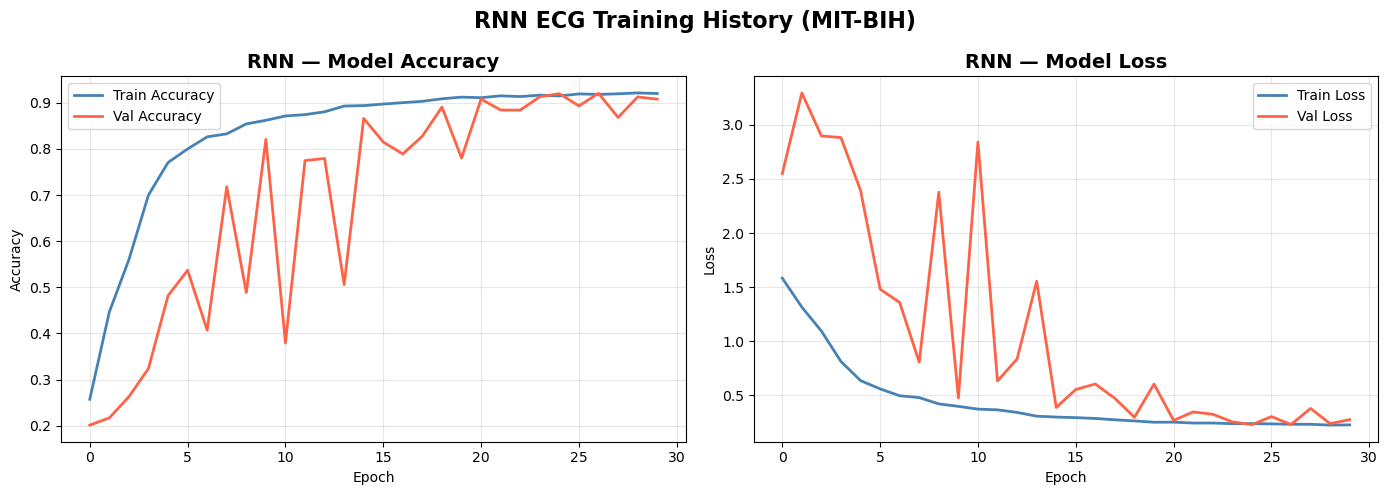

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_accuracy'],
             label='Val Accuracy',   color='tomato',    linewidth=2)
axes[0].set_title('RNN — Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],
             label='Train Loss', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_loss'],
             label='Val Loss',   color='tomato',    linewidth=2)
axes[1].set_title('RNN — Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('RNN ECG Training History (MIT-BIH)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('rnn_accuracy_loss.png', dpi=150, bbox_inches='tight')
plt.show()

CELL 9 — Evaluate Model

In [16]:
# Predictions
y_pred_prob = model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"✅ RNN Test Accuracy: {acc*100:.2f}%")

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(
    y_test, y_pred,
    target_names=list(class_names.values())
))

685/685 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step
✅ RNN Test Accuracy: 87.39%

=== Classification Report ===
                  precision    recall  f1-score   support

          Normal       0.99      0.86      0.92     18118
Supraventricular       0.28      0.76      0.41       556
     Ventricular       0.72      0.95      0.82      1448
          Fusion       0.17      0.86      0.28       162
         Unknown       0.81      0.97      0.89      1608

        accuracy                           0.87     21892
       macro avg       0.60      0.88      0.66     21892
    weighted avg       0.94      0.87      0.90     21892



CELL 10 — Confusion Matrix

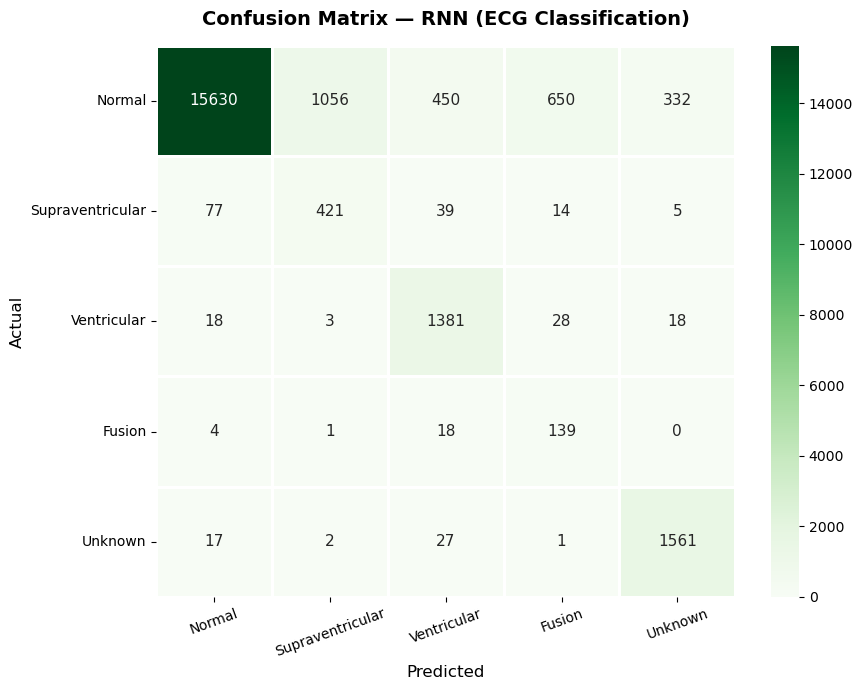

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=list(class_names.values()),
            yticklabels=list(class_names.values()),
            linewidths=0.8, linecolor='white',
            annot_kws={"size": 11})

plt.title('Confusion Matrix — RNN (ECG Classification)',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual',    fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('rnn_confusion_matrix.png', dpi=150)
plt.show()

CELL 11 — Per-Class Accuracy


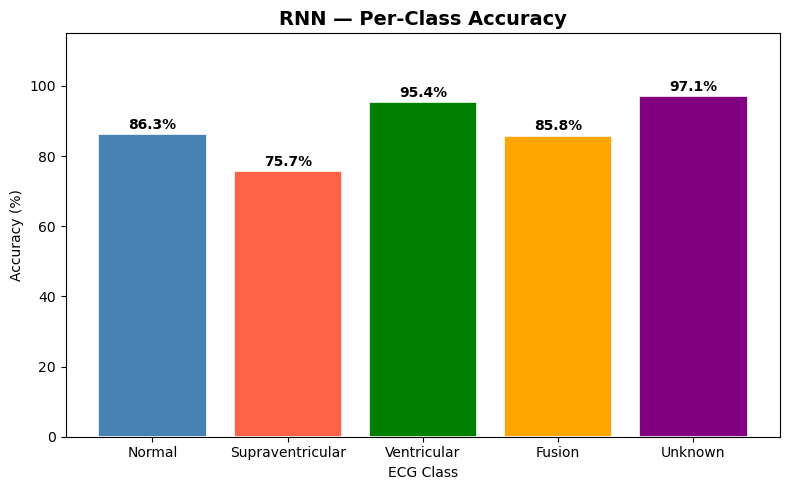

In [18]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    list(class_names.values()),
    per_class_acc * 100,
    color=['steelblue','tomato','green','orange','purple'],
    edgecolor='white', linewidth=1.2
)
plt.title('RNN — Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('ECG Class')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 115)
for bar, val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f'{val*100:.1f}%',
             ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('rnn_per_class_accuracy.png', dpi=150)
plt.show()

CELL 12 — Compare All 3 Models (CNN1D vs LSTM vs RNN)

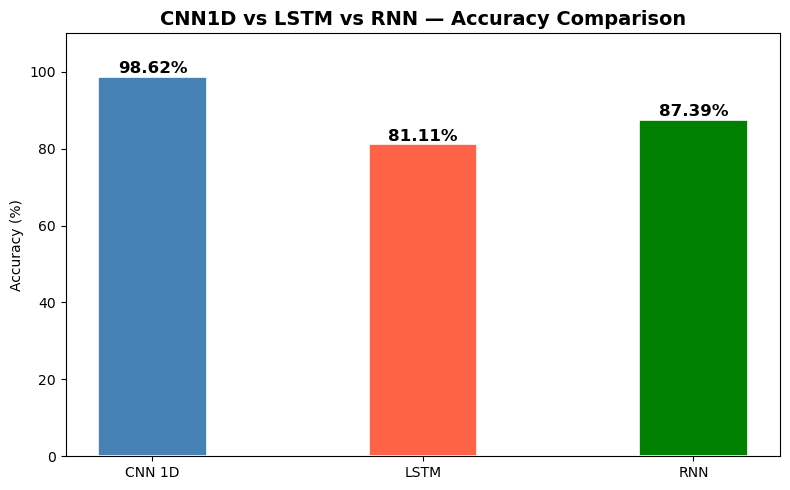

In [ ]:
cnn1d_acc = 98.62   # Your actual CNN1D result
lstm_acc  = 81.11   # Your actual LSTM result
rnn_acc   = acc * 100  # Auto-filled from current run

models     = ['CNN 1D', 'LSTM', 'RNN']
accuracies = [cnn1d_acc, lstm_acc, rnn_acc]
colors     = ['steelblue', 'tomato', 'green']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors,
               edgecolor='white', linewidth=1.2, width=0.4)
plt.title('CNN1D vs LSTM vs RNN — Accuracy Comparison',
          fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
for bar, val in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.2f}%',
             ha='center', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('rnn_vs_lstm_vs_cnn1d.png', dpi=150)
plt.show()

CELL 13 — Save Model

In [20]:
model.save('rnn_ecg_model.h5')
print("✅ RNN model saved as rnn_ecg_model.h5")
print("\n📁 Output files:")
print("   - rnn_accuracy_loss.png")
print("   - rnn_confusion_matrix.png")
print("   - rnn_per_class_accuracy.png")
print("   - rnn_vs_lstm_vs_cnn1d.png")
print("   - rnn_sample_signals.png")
print("   - rnn_ecg_model.h5")

✅ RNN model saved as rnn_ecg_model.h5

📁 Output files:
   - rnn_accuracy_loss.png
   - rnn_confusion_matrix.png
   - rnn_per_class_accuracy.png
   - rnn_vs_lstm_vs_cnn1d.png
   - rnn_sample_signals.png
   - rnn_ecg_model.h5
